# Prediction model for multiple companies


In [1]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Libraries used
import json
import time
import math
import warnings
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import xgboost as xgb

from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

import preprocessing as pp

random_state = 42
mode = "full"  # use "smoke" for a quick test
lookbacks = [1, 3, 7, 15, 30]
unseen_ratio = 0.20
cv_splits = 3
refit_every = 20  # monthly-style refit for a low-resource PC
max_xgb_rounds = 300
early_stopping = 20

if mode == "smoke":
    rf_trials = 3
    et_trials = 3
    xgb_trials = 3
    max_xgb_rounds = 50
    early_stopping = 8
    refit_every = 2
else:
    rf_trials = 20
    et_trials = 20
    xgb_trials = 30

pp.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
# System information
system = pp.print_system_info()
safe_threads = system["safe_threads"]


System
------
CPU physical: 16
CPU logical: 24
RAM available: 2.67 GB
CUDA: True
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
VRAM free: 6.89 GB
Safe CPU threads: 2


In [4]:
# Load processed data
cache_meta = pp._load_meta().get("panel", {})
cache_mode = cache_meta.get("mode")
if not pp._table_exists(pp.PANEL_CACHE) or cache_mode != mode:
    print(f"Panel cache for mode={mode!r} was not found. Running preprocessing first.")
    panel = pp.prepare_all(mode=mode)
else:
    panel = pp._load_table(pp.PANEL_CACHE)

panel["date"] = pd.to_datetime(panel["date"])
panel["target_date"] = pd.to_datetime(panel["target_date"], errors="coerce")
panel = panel.sort_values(["ticker", "date"]).reset_index(drop=True)

print("Rows:", len(panel))
print("Companies:", panel["ticker"].nunique())
print("Date range:", panel["date"].min(), "to", panel["date"].max())

Rows: 424859
Companies: 50
Date range: 1962-01-02 00:00:00 to 2023-12-28 00:00:00


In [5]:
# Split data by time
common = panel[(panel["history_count"] >= pp.REQUIRED_HISTORY) & panel["target_return"].notna()].copy()
all_dates = np.array(sorted(common["date"].unique()))

if len(all_dates) < 60:
    raise ValueError("Not enough trading dates for train / validation / test.")

train_cut = int(len(all_dates) * 0.70)
val_cut = int(len(all_dates) * 0.85)

train_dates = all_dates[:train_cut - 1]
gap_train_val = all_dates[train_cut - 1]
val_dates = all_dates[train_cut:val_cut - 1]
gap_val_test = all_dates[val_cut - 1]
test_dates = all_dates[val_cut:]

print("TRAIN:", pd.Timestamp(train_dates[0]).date(), "to", pd.Timestamp(train_dates[-1]).date())
print("TRAIN-VAL purge:", pd.Timestamp(gap_train_val).date())
print("VALIDATION:", pd.Timestamp(val_dates[0]).date(), "to", pd.Timestamp(val_dates[-1]).date())
print("VAL-TEST purge:", pd.Timestamp(gap_val_test).date())
print("TEST:", pd.Timestamp(test_dates[0]).date(), "to", pd.Timestamp(test_dates[-1]).date())

TRAIN: 1962-02-13 to 2005-06-02
TRAIN-VAL purge: 2005-06-03
VALIDATION: 2005-06-06 to 2014-09-12
VAL-TEST purge: 2014-09-15
TEST: 2014-09-16 to 2023-12-27


In [6]:
# Split seen and unseen companies from TRAIN data
train_period = common[common["date"].isin(train_dates)]
company_stats = (
    train_period.groupby("ticker")
    .agg(train_rows=("date", "size"), train_news=("news_count", "sum"))
    .reset_index()
)

eligible = company_stats[(company_stats["train_rows"] >= 100) & (company_stats["train_news"] >= 10)].copy()
if len(eligible) < 5:
    eligible = company_stats[company_stats["train_rows"] >= 60].copy()
if len(eligible) < 3:
    raise ValueError("Need at least 3 eligible companies for seen/unseen evaluation.")

rng = np.random.default_rng(random_state)
tickers = eligible["ticker"].sort_values().to_numpy()
rng.shuffle(tickers)

n_unseen = min(len(tickers) - 1, max(1, int(round(len(tickers) * unseen_ratio))))
unseen_tickers = sorted(tickers[:n_unseen].tolist())
seen_tickers = sorted(tickers[n_unseen:].tolist())

print("Eligible companies:", len(tickers))
print("Seen companies:", len(seen_tickers))
print("Unseen companies:", len(unseen_tickers))
print("Unseen tickers:", unseen_tickers)

assert set(seen_tickers).isdisjoint(unseen_tickers)

Eligible companies: 40
Seen companies: 32
Unseen companies: 8
Unseen tickers: ['BIIB', 'BSX', 'CI', 'FCX', 'GILD', 'QCOM', 'TXN', 'WFC']


In [7]:
# Save data split information
split_summary = {
    "seen_tickers": seen_tickers,
    "unseen_tickers": unseen_tickers,
    "train_start": str(pd.Timestamp(train_dates[0])),
    "train_end": str(pd.Timestamp(train_dates[-1])),
    "train_validation_purge": str(pd.Timestamp(gap_train_val)),
    "validation_start": str(pd.Timestamp(val_dates[0])),
    "validation_end": str(pd.Timestamp(val_dates[-1])),
    "validation_test_purge": str(pd.Timestamp(gap_val_test)),
    "test_start": str(pd.Timestamp(test_dates[0])),
    "test_end": str(pd.Timestamp(test_dates[-1])),
}
with open(pp.OUTPUT_DIR / "split_summary.json", "w") as f:
    json.dump(split_summary, f, indent=2)
print("Saved split_summary.json")

Saved split_summary.json


In [8]:
# Helper functions
def get_labeled_data(lookback):
    data = pp.make_lookback_features(panel, lookback, min_history=pp.REQUIRED_HISTORY)
    features = pp.model_feature_columns()
    data = data[data["target_return"].notna()].copy()
    data = data.dropna(subset=features + ["target_return"])
    data = data.replace([np.inf, -np.inf], np.nan).dropna(subset=features + ["target_return"])
    return data, features


def date_cv_splits(df, n_splits=3, gap=1):
    dates = np.array(sorted(df["date"].unique()))
    splitter = TimeSeriesSplit(n_splits=n_splits, gap=gap)
    splits = []
    for train_date_idx, val_date_idx in splitter.split(dates):
        tr_dates = set(dates[train_date_idx])
        va_dates = set(dates[val_date_idx])
        val_start = pd.Timestamp(min(va_dates))
        train_mask = df["date"].isin(tr_dates) & (df["target_date"] < val_start)
        val_mask = df["date"].isin(va_dates)
        tr_idx = np.flatnonzero(train_mask.to_numpy())
        va_idx = np.flatnonzero(val_mask.to_numpy())
        assert df.iloc[tr_idx]["target_date"].max() < df.iloc[va_idx]["date"].min()
        splits.append((tr_idx, va_idx))
    return splits


def metrics(y_true, pred):
    return {
        "mae": mean_absolute_error(y_true, pred),
        "rmse": mean_squared_error(y_true, pred) ** 0.5,
        "r2": r2_score(y_true, pred),
        "direction": float((np.sign(y_true) == np.sign(pred)).mean()),
    }


def metrics_for_frame(frame, pred):
    result = metrics(frame["target_return"].to_numpy(), pred)
    predicted_open = frame["close"].to_numpy() * (1 + pred)
    actual_open = frame["target_open"].to_numpy()
    naive_open = frame["close"].to_numpy()
    result["open_mae"] = mean_absolute_error(actual_open, predicted_open)
    result["open_rmse"] = mean_squared_error(actual_open, predicted_open) ** 0.5
    result["naive_open_mae"] = mean_absolute_error(actual_open, naive_open)
    result["naive_open_rmse"] = mean_squared_error(actual_open, naive_open) ** 0.5
    return result


def trial_table(study, model_name):
    rows = []
    for trial in study.trials:
        rows.append({
            "model": model_name,
            "trial": trial.number,
            "value": trial.value,
            "state": str(trial.state),
            "cv_std": trial.user_attrs.get("cv_std"),
            "fold_mae": json.dumps(trial.user_attrs.get("fold_mae")),
            "duration_sec": trial.duration.total_seconds() if trial.duration else None,
            "params": json.dumps(trial.params),
        })
    return pd.DataFrame(rows)

## 1. Choose lookback
I try 5 lookback periods on TRAIN to choose the most suitable one.


In [9]:
# Try different lookback values
lookback_rows = []
lookback_fold_rows = []
for lookback in lookbacks:
    data_lb, features_lb = get_labeled_data(lookback)
    train_lb = data_lb[data_lb["ticker"].isin(seen_tickers) & data_lb["date"].isin(train_dates)].copy()
    fold_mae = []
    start = time.perf_counter()

    for fold, (tr_idx, va_idx) in enumerate(date_cv_splits(train_lb, cv_splits, gap=1), 1):
        tr = train_lb.iloc[tr_idx]
        va = train_lb.iloc[va_idx]
        model = ExtraTreesRegressor(
            n_estimators=120 if mode == "full" else 40,
            max_depth=8,
            min_samples_leaf=3,
            max_features="sqrt",
            random_state=random_state,
            n_jobs=safe_threads,
        )
        model.fit(tr[features_lb], tr["target_return"])
        pred = model.predict(va[features_lb])
        score = mean_absolute_error(va["target_return"], pred)
        fold_mae.append(score)
        lookback_fold_rows.append({"lookback": lookback, "fold": fold, "mae": score})
        print(f"Lookback {lookback:>2} | fold {fold} | MAE {score:.6f}")

    lookback_rows.append({
        "lookback": lookback,
        "cv_mae": float(np.mean(fold_mae)),
        "cv_std": float(np.std(fold_mae)),
        "time_sec": time.perf_counter() - start,
    })

lookback_results = pd.DataFrame(lookback_rows).sort_values("cv_mae").reset_index(drop=True)
lookback_results.to_csv(pp.OUTPUT_DIR / "lookback_search.csv", index=False)
pd.DataFrame(lookback_fold_rows).to_csv(pp.OUTPUT_DIR / "lookback_fold_results.csv", index=False)
display(lookback_results)

best_lookback = int(lookback_results.iloc[0]["lookback"])
print("Best lookback:", best_lookback, "trading sessions")

Lookback  1 | fold 1 | MAE 0.005027
Lookback  1 | fold 2 | MAE 0.005449
Lookback  1 | fold 3 | MAE 0.007672
Lookback  3 | fold 1 | MAE 0.004886
Lookback  3 | fold 2 | MAE 0.005433
Lookback  3 | fold 3 | MAE 0.007656
Lookback  7 | fold 1 | MAE 0.004403
Lookback  7 | fold 2 | MAE 0.005370
Lookback  7 | fold 3 | MAE 0.007629
Lookback 15 | fold 1 | MAE 0.003977
Lookback 15 | fold 2 | MAE 0.005306
Lookback 15 | fold 3 | MAE 0.007604
Lookback 30 | fold 1 | MAE 0.003930
Lookback 30 | fold 2 | MAE 0.005376
Lookback 30 | fold 3 | MAE 0.007609


,lookback,cv_mae,cv_std,time_sec
0,15,0.005629,0.001498,0.736862
1,30,0.005638,0.001514,0.733422
2,7,0.005801,0.001352,0.743654
3,3,0.005992,0.001198,0.727473
4,1,0.006049,0.001160,0.633863


Best lookback: 15 trading sessions


In [10]:
# Create the dataset with the selected lookback
data, features = get_labeled_data(best_lookback)
validation_start = pd.Timestamp(val_dates[0])
test_start = pd.Timestamp(test_dates[0])

train = data[
    data["ticker"].isin(seen_tickers)
    & data["date"].isin(train_dates)
    & (data["target_date"] < validation_start)
].copy()
validation = data[
    data["ticker"].isin(seen_tickers)
    & data["date"].isin(val_dates)
    & (data["target_date"] < test_start)
].copy()
test_seen = data[data["ticker"].isin(seen_tickers) & data["date"].isin(test_dates)].copy()
test_unseen = data[data["ticker"].isin(unseen_tickers) & data["date"].isin(test_dates)].copy()

print("Features:", features)
print("TRAIN rows:", len(train))
print("VALIDATION rows:", len(validation))
print("TEST seen rows:", len(test_seen))
print("TEST unseen rows:", len(test_unseen))

assert train["date"].max() < validation["date"].min()
assert validation["date"].max() < test_seen["date"].min()
assert not set(unseen_tickers) & set(train["ticker"])
assert not set(unseen_tickers) & set(validation["ticker"])
assert "target_return" not in features
assert "target_open" not in features

Features: ['daily_return', 'open_gap', 'intraday_return', 'high_low_range', 'volume_change', 'sentiment_mean', 'sentiment_std', 'news_count', 'return_mean_lb', 'return_vol_lb', 'volume_change_mean_lb', 'sentiment_mean_lb', 'sentiment_std_lb', 'news_count_lb']
TRAIN rows: 152207
VALIDATION rows: 74720
TEST seen rows: 73842
TEST unseen rows: 17739


## 2. Choose the learning rate for XGBoost
After choosing the lookback, I try different learning rate settings for XGBoost on TRAIN.


In [11]:
# Check whether XGBoost uses CPU or GPU
def choose_xgb_device():
    # Probe XGBoost itself. PyTorch and XGBoost can have different CUDA builds,
    # and XGBoost may silently fall back to CPU with only a warning.
    try:
        d = xgb.DMatrix(
            np.array([[0.0], [1.0]], dtype=np.float32),
            label=np.array([0.0, 1.0], dtype=np.float32),
        )
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            booster = xgb.train(
                {
                    "objective": "reg:squarederror",
                    "tree_method": "hist",
                    "device": "cuda",
                    "verbosity": 0,
                    "nthread": safe_threads,
                },
                d,
                num_boost_round=1,
                verbose_eval=False,
            )
        config = json.loads(booster.save_config())
        actual = str(config["learner"]["generic_param"]["device"])
        if actual.startswith("cuda"):
            return "cuda"
    except Exception as e:
        print("XGBoost CUDA probe failed:", type(e).__name__)

    return "cpu"

xgb_device = choose_xgb_device()
print("XGBoost device:", xgb_device)


XGBoost device: cuda


In [12]:
# Different learning rate settings
def lr_value(name, epoch, total_rounds):
    if name == "constant_003":
        return 0.03
    if name == "constant_010":
        return 0.10
    if name == "exponential":
        return max(0.01, 0.10 * (0.99 ** epoch))
    if name == "step_decay":
        if epoch < total_rounds * 0.33:
            return 0.10
        if epoch < total_rounds * 0.66:
            return 0.05
        return 0.02
    if name == "cosine":
        low, high = 0.01, 0.10
        progress = min(epoch / max(total_rounds - 1, 1), 1.0)
        return low + 0.5 * (high - low) * (1 + math.cos(math.pi * progress))
    raise ValueError(name)


def train_xgb_once(X_train, y_train, X_val, y_val, params, lr_name, rounds, early_stopping=True):
    global xgb_device
    dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
    dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

    def run(device):
        history = {}
        callback = xgb.callback.LearningRateScheduler(lambda epoch: lr_value(lr_name, epoch, max_xgb_rounds))
        train_params = dict(params)
        train_params.update({
            "tree_method": "hist",
            "device": device,
            "nthread": safe_threads,
            "seed": random_state,
            "eval_metric": ["rmse", "mae"],
        })
        kwargs = {"early_stopping_rounds": early_stopping} if early_stopping else {}
        booster = xgb.train(
            train_params,
            dtrain,
            num_boost_round=rounds,
            evals=[(dtrain, "train"), (dval, "valid")],
            evals_result=history,
            callbacks=[callback],
            verbose_eval=False,
            **kwargs,
        )
        return booster, history

    try:
        booster, history = run(xgb_device)
    except Exception:
        if xgb_device != "cuda":
            raise
        print("XGBoost CUDA training failed. Retrying on CPU.")
        xgb_device = "cpu"
        booster, history = run("cpu")

    best_iteration = getattr(booster, "best_iteration", len(history["valid"]["mae"]) - 1)
    use_rounds = best_iteration + 1 if early_stopping else rounds
    pred = booster.predict(dval, iteration_range=(0, use_rounds))
    return booster, pred, history, int(use_rounds - 1)


def train_xgb_fixed(X_train, y_train, params, lr_name, rounds):
    global xgb_device
    dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)

    def run(device):
        train_params = dict(params)
        train_params.update({
            "tree_method": "hist",
            "device": device,
            "nthread": safe_threads,
            "seed": random_state,
        })
        callback = xgb.callback.LearningRateScheduler(lambda epoch: lr_value(lr_name, epoch, max_xgb_rounds))
        return xgb.train(
            train_params,
            dtrain,
            num_boost_round=rounds,
            callbacks=[callback],
            verbose_eval=False,
        )

    try:
        return run(xgb_device)
    except Exception:
        if xgb_device != "cuda":
            raise
        print("XGBoost CUDA training failed. Retrying on CPU.")
        xgb_device = "cpu"
        return run("cpu")


def history_rows(history, lr_name, model_stage, fold=None, trial=None):
    rows = []
    n = len(history["valid"]["mae"])
    for epoch in range(n):
        rows.append({
            "stage": model_stage,
            "trial": trial,
            "fold": fold,
            "epoch": epoch + 1,
            "learning_rate": lr_value(lr_name, epoch, max_xgb_rounds),
            "train_mae": float(history["train"]["mae"][epoch]),
            "valid_mae": float(history["valid"]["mae"][epoch]),
            "train_rmse": float(history["train"]["rmse"][epoch]),
            "valid_rmse": float(history["valid"]["rmse"][epoch]),
            "lr_strategy": lr_name,
        })
    return rows

In [13]:
# Try learning rates on TRAIN
lr_candidates = ["constant_003", "constant_010", "exponential", "step_decay", "cosine"]
if mode == "smoke":
    lr_candidates = ["constant_003", "step_decay"]

fixed_xgb = {
    "objective": "reg:squarederror",
    "max_depth": 4,
    "min_child_weight": 3,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "gamma": 0.0,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
}

lr_summary = []
lr_epoch_rows = []

for lr_name in lr_candidates:
    fold_scores = []
    best_epochs = []
    start = time.perf_counter()
    for fold, (tr_idx, va_idx) in enumerate(date_cv_splits(train, cv_splits, gap=1), 1):
        tr = train.iloc[tr_idx]
        va = train.iloc[va_idx]
        booster, pred, hist, best_iter = train_xgb_once(
            tr[features], tr["target_return"],
            va[features], va["target_return"],
            fixed_xgb, lr_name, max_xgb_rounds,
        )
        score = mean_absolute_error(va["target_return"], pred)
        fold_scores.append(score)
        best_epochs.append(best_iter + 1)
        lr_epoch_rows.extend(history_rows(hist, lr_name, "lr_search", fold=fold))
        print(f"{lr_name:>14} | fold {fold} | best epoch {best_iter + 1} | MAE {score:.6f}")

    lr_summary.append({
        "lr_strategy": lr_name,
        "cv_mae": float(np.mean(fold_scores)),
        "cv_std": float(np.std(fold_scores)),
        "mean_best_epoch": float(np.mean(best_epochs)),
        "time_sec": time.perf_counter() - start,
    })

lr_results = pd.DataFrame(lr_summary).sort_values("cv_mae").reset_index(drop=True)
pd.DataFrame(lr_epoch_rows).to_csv(pp.OUTPUT_DIR / "lr_search_epoch_history.csv", index=False)
lr_results.to_csv(pp.OUTPUT_DIR / "lr_search_summary.csv", index=False)
display(lr_results)

best_lr = lr_results.iloc[0]["lr_strategy"]
print("Best learning-rate strategy:", best_lr)

  constant_003 | fold 1 | best epoch 2 | MAE 0.003985
  constant_003 | fold 2 | best epoch 1 | MAE 0.005220
  constant_003 | fold 3 | best epoch 2 | MAE 0.007620
  constant_010 | fold 1 | best epoch 2 | MAE 0.003983
  constant_010 | fold 2 | best epoch 1 | MAE 0.005220
  constant_010 | fold 3 | best epoch 1 | MAE 0.007620
   exponential | fold 1 | best epoch 2 | MAE 0.003983
   exponential | fold 2 | best epoch 1 | MAE 0.005220
   exponential | fold 3 | best epoch 1 | MAE 0.007620
    step_decay | fold 1 | best epoch 2 | MAE 0.003983
    step_decay | fold 2 | best epoch 1 | MAE 0.005220
    step_decay | fold 3 | best epoch 1 | MAE 0.007620
        cosine | fold 1 | best epoch 2 | MAE 0.003983
        cosine | fold 2 | best epoch 1 | MAE 0.005220
        cosine | fold 3 | best epoch 1 | MAE 0.007620


,lr_strategy,cv_mae,cv_std,mean_best_epoch,time_sec
0,constant_010,0.005608,0.001510,1.333333,0.616024
1,exponential,0.005608,0.001510,1.333333,0.671655
2,step_decay,0.005608,0.001510,1.333333,0.639594
3,cosine,0.005608,0.001510,1.333333,0.629792
4,constant_003,0.005608,0.001509,1.666667,0.725700


Best learning-rate strategy: constant_010


## 3. Tune parameters
Keep the selected lookback and learning rate, then tune the parameters for each model on TRAIN.


In [14]:
# Tune Random Forest
def rf_objective(trial):
    bootstrap = trial.suggest_categorical("bootstrap", [True, False])
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 150 if mode == "full" else 50, 600 if mode == "full" else 200, step=50),
        "criterion": trial.suggest_categorical("criterion", ["squared_error", "friedman_mse"]),
        "max_depth": trial.suggest_categorical("max_depth", [None, 4, 6, 8, 12, 16, 24]),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 16),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 8),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.75, 1.0]),
        "bootstrap": bootstrap,
        "random_state": random_state,
        "n_jobs": safe_threads,
    }
    if bootstrap:
        params["max_samples"] = trial.suggest_float("max_samples", 0.5, 1.0)

    scores = []
    for tr_idx, va_idx in date_cv_splits(train, cv_splits, gap=1):
        tr = train.iloc[tr_idx]
        va = train.iloc[va_idx]
        model = RandomForestRegressor(**params)
        model.fit(tr[features], tr["target_return"])
        pred = model.predict(va[features])
        scores.append(mean_absolute_error(va["target_return"], pred))
    trial.set_user_attr("cv_std", float(np.std(scores)))
    trial.set_user_attr("fold_mae", [float(x) for x in scores])
    return float(np.mean(scores))

rf_start = time.perf_counter()
rf_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=random_state))
rf_study.optimize(rf_objective, n_trials=rf_trials, n_jobs=1, show_progress_bar=True)
rf_time = time.perf_counter() - rf_start
rf_trials = trial_table(rf_study, "RandomForest")
rf_trials.to_csv(pp.OUTPUT_DIR / "rf_trials.csv", index=False)
print("Best RF CV MAE:", rf_study.best_value)
print("Best RF params:", rf_study.best_params)
display(rf_trials.sort_values("value").head(5))

  0%|          | 0/20 [00:00<?, ?it/s]

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_forest.py:1942: FutureWarning: Value `"friedman_mse"` for `criterion` is deprecated and will be removed in 1.11. It maps to `"squared_error"` as both were always equivalent. Use `criterion="squared_error"` to remove this warning.
  warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_forest.py:1942: FutureWarning: Value `"friedman_mse"` for `criterion` is deprecated and will be removed in 1.11. It maps to `"squared_error"` as both were always equivalent. Use `criterion="squared_error"` to remove this warning.
  warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_forest.py:1942: FutureWarning: Value `"friedman_mse"` for `criterion` is deprecated and will be removed in 1.11. It maps to `"squared_error"` as both were always equivalent. Use `criterion="squared_error"` to remove this warning.
  warn(
c:\Users\Admi

Best RF CV MAE: 0.0056584613752261705
Best RF params: {'bootstrap': False, 'n_estimators': 200, 'criterion': 'friedman_mse', 'max_depth': 4, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2'}


,model,trial,value,state,cv_std,fold_mae,duration_sec,params
1,RandomForest,1,0.005658,TrialState.COMPLETE,0.001484,"[0.0039912710794010355, 0.005387969518154711, ...",6.311992,"{""bootstrap"": false, ""n_estimators"": 200, ""cri..."
11,RandomForest,11,0.005670,TrialState.COMPLETE,0.001481,"[0.003990283870345248, 0.0054259488308442015, ...",10.968156,"{""bootstrap"": false, ""n_estimators"": 350, ""cri..."
10,RandomForest,10,0.005670,TrialState.COMPLETE,0.001481,"[0.003990283870345248, 0.0054259488308442015, ...",11.224485,"{""bootstrap"": false, ""n_estimators"": 350, ""cri..."
15,RandomForest,15,0.005675,TrialState.COMPLETE,0.001482,"[0.003989354744576518, 0.0054386558319042475, ...",4.880232,"{""bootstrap"": false, ""n_estimators"": 150, ""cri..."
16,RandomForest,16,0.005679,TrialState.COMPLETE,0.001479,"[0.003990806344102523, 0.005451971434220938, 0...",11.268876,"{""bootstrap"": false, ""n_estimators"": 350, ""cri..."


In [15]:
# Tune Extra Trees
def et_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 150 if mode == "full" else 50, 600 if mode == "full" else 200, step=50),
        "criterion": trial.suggest_categorical("criterion", ["squared_error", "friedman_mse"]),
        "max_depth": trial.suggest_categorical("max_depth", [None, 4, 6, 8, 12, 16, 24]),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 16),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 8),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.75, 1.0]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": random_state,
        "n_jobs": safe_threads,
    }
    scores = []
    for tr_idx, va_idx in date_cv_splits(train, cv_splits, gap=1):
        tr = train.iloc[tr_idx]
        va = train.iloc[va_idx]
        model = ExtraTreesRegressor(**params)
        model.fit(tr[features], tr["target_return"])
        pred = model.predict(va[features])
        scores.append(mean_absolute_error(va["target_return"], pred))
    trial.set_user_attr("cv_std", float(np.std(scores)))
    trial.set_user_attr("fold_mae", [float(x) for x in scores])
    return float(np.mean(scores))

et_start = time.perf_counter()
et_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=random_state))
et_study.optimize(et_objective, n_trials=et_trials, n_jobs=1, show_progress_bar=True)
et_time = time.perf_counter() - et_start
et_trials = trial_table(et_study, "ExtraTrees")
et_trials.to_csv(pp.OUTPUT_DIR / "extra_trees_trials.csv", index=False)
print("Best ET CV MAE:", et_study.best_value)
print("Best ET params:", et_study.best_params)
display(et_trials.sort_values("value").head(5))

  0%|          | 0/20 [00:00<?, ?it/s]

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_forest.py:2694: FutureWarning: Value `"friedman_mse"` for `criterion` is deprecated and will be removed in 1.11. It maps to `"squared_error"` as both were always equivalent. Use `criterion="squared_error"` to remove this warning.
  warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_forest.py:2694: FutureWarning: Value `"friedman_mse"` for `criterion` is deprecated and will be removed in 1.11. It maps to `"squared_error"` as both were always equivalent. Use `criterion="squared_error"` to remove this warning.
  warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_forest.py:2694: FutureWarning: Value `"friedman_mse"` for `criterion` is deprecated and will be removed in 1.11. It maps to `"squared_error"` as both were always equivalent. Use `criterion="squared_error"` to remove this warning.
  warn(
c:\Users\Admi

Best ET CV MAE: 0.00560432034406629
Best ET params: {'n_estimators': 500, 'criterion': 'friedman_mse', 'max_depth': 4, 'min_samples_split': 12, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': False}


,model,trial,value,state,cv_std,fold_mae,duration_sec,params
4,ExtraTrees,4,0.005604,TrialState.COMPLETE,0.001503,"[0.003979723906749401, 0.0052302874519183935, ...",1.760109,"{""n_estimators"": 500, ""criterion"": ""friedman_m..."
8,ExtraTrees,8,0.005609,TrialState.COMPLETE,0.001502,"[0.003977541909639961, 0.005246406313746016, 0...",0.943047,"{""n_estimators"": 200, ""criterion"": ""friedman_m..."
0,ExtraTrees,0,0.005610,TrialState.COMPLETE,0.001501,"[0.003979316980417991, 0.0052496506494466915, ...",1.754675,"{""n_estimators"": 300, ""criterion"": ""squared_er..."
9,ExtraTrees,9,0.005610,TrialState.COMPLETE,0.001501,"[0.003978936959885845, 0.005249409813394382, 0...",1.032318,"{""n_estimators"": 150, ""criterion"": ""squared_er..."
16,ExtraTrees,16,0.005618,TrialState.COMPLETE,0.001499,"[0.00397604429382703, 0.005276171171882575, 0....",3.615802,"{""n_estimators"": 550, ""criterion"": ""friedman_m..."


In [16]:
# Check the XGBoost objective
def supported_objectives():
    candidates = ["reg:squarederror", "reg:absoluteerror", "reg:pseudohubererror"]
    supported = []
    x_small = train[features].head(30)
    y_small = train["target_return"].head(30)
    dsmall = xgb.DMatrix(x_small, label=y_small, feature_names=features)
    for objective in candidates:
        try:
            xgb.train({"objective": objective, "tree_method": "hist", "device": xgb_device}, dsmall, num_boost_round=1, verbose_eval=False)
            supported.append(objective)
        except Exception:
            print("Skipping unsupported objective:", objective)
    return supported

xgb_objectives = supported_objectives()
print("XGBoost objectives:", xgb_objectives)

XGBoost objectives: ['reg:squarederror', 'reg:absoluteerror', 'reg:pseudohubererror']


In [17]:
# Tune XGBoost and save each trial result
xgb_epoch_rows = []

def xgb_objective(trial):
    params = {
        "objective": trial.suggest_categorical("objective", xgb_objectives),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 12.0),
        "subsample": trial.suggest_float("subsample", 0.55, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.55, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 4.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-7, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 50.0, log=True),
    }

    scores = []
    best_rounds = []
    for fold, (tr_idx, va_idx) in enumerate(date_cv_splits(train, cv_splits, gap=1), 1):
        tr = train.iloc[tr_idx]
        va = train.iloc[va_idx]
        booster, pred, hist, best_iter = train_xgb_once(
            tr[features], tr["target_return"],
            va[features], va["target_return"],
            params, best_lr, max_xgb_rounds,
        )
        score = mean_absolute_error(va["target_return"], pred)
        scores.append(score)
        best_rounds.append(best_iter + 1)
        xgb_epoch_rows.extend(history_rows(hist, best_lr, "xgb_optuna", fold=fold, trial=trial.number))

    trial.set_user_attr("cv_std", float(np.std(scores)))
    trial.set_user_attr("fold_mae", [float(x) for x in scores])
    trial.set_user_attr("best_rounds", [int(x) for x in best_rounds])
    return float(np.mean(scores))

xgb_start = time.perf_counter()
xgb_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=random_state))
xgb_study.optimize(xgb_objective, n_trials=xgb_trials, n_jobs=1, show_progress_bar=True)
xgb_time = time.perf_counter() - xgb_start
xgb_trials = trial_table(xgb_study, "XGBoost")
xgb_trials.to_csv(pp.OUTPUT_DIR / "xgb_trials.csv", index=False)
pd.DataFrame(xgb_epoch_rows).to_csv(pp.OUTPUT_DIR / "xgb_optuna_epoch_history.csv", index=False)
print("Best XGB CV MAE:", xgb_study.best_value)
print("Best XGB params:", xgb_study.best_params)
xgb_cv_rounds = max(1, int(round(np.median(xgb_study.best_trial.user_attrs["best_rounds"]))))
print("XGBoost rounds frozen from TRAIN CV:", xgb_cv_rounds)
display(xgb_trials.sort_values("value").head(5))

  0%|          | 0/30 [00:00<?, ?it/s]

Best XGB CV MAE: 0.005443758080802375
Best XGB params: {'objective': 'reg:absoluteerror', 'max_depth': 4, 'min_child_weight': 5.515606213765154, 'subsample': 0.6507881766571083, 'colsample_bytree': 0.6359831787244055, 'gamma': 3.0454369221648867, 'reg_alpha': 4.918751487357874e-06, 'reg_lambda': 0.44659110258804385}
XGBoost rounds frozen from TRAIN CV: 14


,model,trial,value,state,cv_std,fold_mae,duration_sec,params
14,XGBoost,14,0.005444,TrialState.COMPLETE,0.001583,"[0.003746082343336803, 0.00502958171120862, 0....",1.200074,"{""objective"": ""reg:absoluteerror"", ""max_depth""..."
28,XGBoost,28,0.005444,TrialState.COMPLETE,0.001583,"[0.0037459874060569893, 0.005029699271135269, ...",1.036436,"{""objective"": ""reg:absoluteerror"", ""max_depth""..."
18,XGBoost,18,0.005444,TrialState.COMPLETE,0.001583,"[0.003746129881872143, 0.005029593220569428, 0...",1.190352,"{""objective"": ""reg:absoluteerror"", ""max_depth""..."
21,XGBoost,21,0.005444,TrialState.COMPLETE,0.001583,"[0.0037459207740174433, 0.0050297745778491035,...",1.053816,"{""objective"": ""reg:absoluteerror"", ""max_depth""..."
1,XGBoost,1,0.005444,TrialState.COMPLETE,0.001583,"[0.00374613319828994, 0.005029633078059355, 0....",1.146250,"{""objective"": ""reg:absoluteerror"", ""max_depth""..."


## 4. Check on validation
Compare the model results and check the training process.


In [18]:
# Final model parameters
rf_params = dict(rf_study.best_params)
if not rf_params["bootstrap"]:
    rf_params.pop("max_samples", None)
rf_params.update(random_state=random_state, n_jobs=safe_threads)

et_params = dict(et_study.best_params)
et_params.update(random_state=random_state, n_jobs=safe_threads)

xgb_params = dict(xgb_study.best_params)


In [19]:
# Compare models on validation
validation_rows = []
validation_models = {}

rf_model = RandomForestRegressor(**rf_params)
start = time.perf_counter()
rf_model.fit(train[features], train["target_return"])
rf_pred = rf_model.predict(validation[features])
rf_m = metrics_for_frame(validation, rf_pred)
validation_rows.append({"model": "RandomForest", **rf_m, "fit_sec": time.perf_counter() - start})
validation_models["RandomForest"] = rf_model

et_model = ExtraTreesRegressor(**et_params)
start = time.perf_counter()
et_model.fit(train[features], train["target_return"])
et_pred = et_model.predict(validation[features])
et_m = metrics_for_frame(validation, et_pred)
validation_rows.append({"model": "ExtraTrees", **et_m, "fit_sec": time.perf_counter() - start})
validation_models["ExtraTrees"] = et_model

start = time.perf_counter()
xgb_model, xgb_pred, xgb_val_history, xgb_best_iter = train_xgb_once(
    train[features], train["target_return"],
    validation[features], validation["target_return"],
    xgb_params, best_lr, xgb_cv_rounds, early_stopping=False,
)
xgb_m = metrics_for_frame(validation, xgb_pred)
validation_rows.append({"model": "XGBoost", **xgb_m, "fit_sec": time.perf_counter() - start})
pd.DataFrame(history_rows(xgb_val_history, best_lr, "xgb_validation")).to_csv(pp.OUTPUT_DIR / "xgb_validation_epoch_history.csv", index=False)
validation_models["XGBoost"] = xgb_model

naive_pred = np.zeros(len(validation))
naive_m = metrics_for_frame(validation, naive_pred)
validation_rows.append({"model": "Naive", **naive_m, "fit_sec": 0.0})

validation_results = pd.DataFrame(validation_rows).sort_values("mae", kind="stable").reset_index(drop=True)
validation_results.to_csv(pp.OUTPUT_DIR / "validation_results.csv", index=False)
display(validation_results)

best_ml_row = validation_results[validation_results["model"] != "Naive"].sort_values("mae", kind="stable").iloc[0]
naive_row = validation_results[validation_results["model"] == "Naive"].iloc[0]
best_ml_model = str(best_ml_row["model"])
ml_beats_naive = float(best_ml_row["mae"]) < float(naive_row["mae"])
selected_model = best_ml_model if ml_beats_naive else "Naive"
validation_mae_improvement = float(naive_row["mae"] - best_ml_row["mae"])
print("Selected model:", selected_model)
print("Best ML model:", best_ml_model)
print("ML beats Naive on validation:", ml_beats_naive)
print("Validation MAE improvement vs Naive:", validation_mae_improvement)
print("XGBoost rounds frozen from TRAIN CV:", xgb_best_iter + 1)

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_forest.py:1942: FutureWarning: Value `"friedman_mse"` for `criterion` is deprecated and will be removed in 1.11. It maps to `"squared_error"` as both were always equivalent. Use `criterion="squared_error"` to remove this warning.
  warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_forest.py:2694: FutureWarning: Value `"friedman_mse"` for `criterion` is deprecated and will be removed in 1.11. It maps to `"squared_error"` as both were always equivalent. Use `criterion="squared_error"` to remove this warning.
  warn(


,model,mae,rmse,r2,direction,open_mae,open_rmse,naive_open_mae,naive_open_rmse,fit_sec
0,ExtraTrees,0.007440,0.014019,0.000651,0.509087,0.322382,1.239212,0.322547,1.235301,1.571331
1,XGBoost,0.007440,0.014027,-0.000513,0.508887,0.322372,1.235292,0.322547,1.235301,0.229708
2,Naive,0.007443,0.014031,-0.001082,0.041341,0.322547,1.235301,0.322547,1.235301,0.000000
3,RandomForest,0.007449,0.014046,-0.003244,0.509275,0.322876,1.245862,0.322547,1.235301,8.452509


Selected model: ExtraTrees
Best ML model: ExtraTrees
ML beats Naive on validation: True
Validation MAE improvement vs Naive: 3.1105816720696303e-06
XGBoost rounds frozen from TRAIN CV: 14


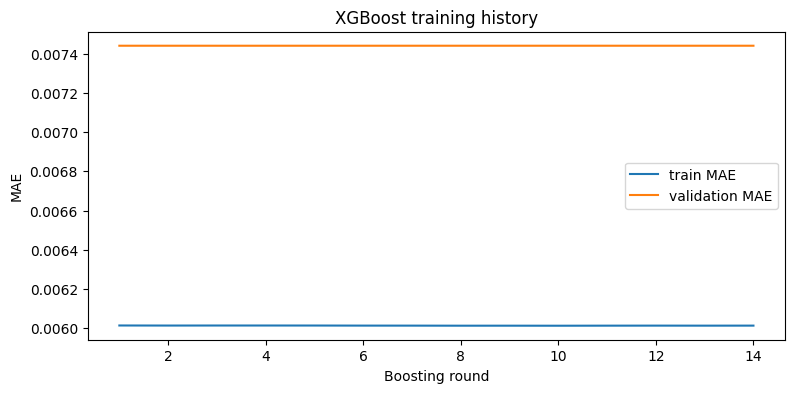

In [20]:
# Plot XGBoost training history
hist_df = pd.read_csv(pp.OUTPUT_DIR / "xgb_validation_epoch_history.csv")
plt.figure(figsize=(9, 4))
plt.plot(hist_df["epoch"], hist_df["train_mae"], label="train MAE")
plt.plot(hist_df["epoch"], hist_df["valid_mae"], label="validation MAE")
plt.xlabel("Boosting round")
plt.ylabel("MAE")
plt.title("XGBoost training history")
plt.legend()
plt.show()

## 5. Evaluate on TEST
TEST is kept separate until this step. For each prediction, the model only learns from data available before the prediction time.


In [21]:
# Train model theo walk-forward
def fit_selected(history):
    if selected_model == "Naive":
        return None
    if selected_model == "RandomForest":
        model = RandomForestRegressor(**rf_params)
        model.fit(history[features], history["target_return"])
        return model

    if selected_model == "ExtraTrees":
        model = ExtraTreesRegressor(**et_params)
        model.fit(history[features], history["target_return"])
        return model

    return train_xgb_fixed(
        history[features], history["target_return"],
        xgb_params, best_lr, xgb_best_iter + 1,
    )


def predict_selected(model, frame):
    if selected_model == "Naive":
        return np.zeros(len(frame), dtype=float)
    if selected_model == "XGBoost":
        return model.predict(xgb.DMatrix(frame[features], feature_names=features))
    return model.predict(frame[features])

all_test_dates = sorted(set(test_seen["date"]) | set(test_unseen["date"]))
if mode == "smoke":
    all_test_dates = all_test_dates[:10]

seen_rows = []
unseen_rows = []
walk_audit_rows = []
walk_start = time.perf_counter()

model = None
last_fit_date = None

for step, current_date in enumerate(all_test_dates, 1):
    # Only use labels available at training time.
    history = data[
        data["ticker"].isin(seen_tickers)
        & data["target_return"].notna()
        & (data["target_date"] <= current_date)
    ].copy()

    current_seen = test_seen[test_seen["date"] == current_date]
    current_unseen = test_unseen[test_unseen["date"] == current_date]
    if current_seen.empty and current_unseen.empty:
        continue

    walk_audit_rows.append({
        "current_date": current_date,
        "max_history_target_date": history["target_date"].max(),
        "history_has_unseen": bool(history["ticker"].isin(unseen_tickers).any()),
    })

    if selected_model == "Naive":
        retrained = False
    else:
        retrained = model is None or (step - 1) % refit_every == 0
        if retrained:
            model = fit_selected(history)
            last_fit_date = current_date

    for group_name, current, store in [("seen", current_seen, seen_rows), ("unseen", current_unseen, unseen_rows)]:
        if current.empty:
            continue
        pred_return = predict_selected(model, current)
        predicted_open = current["close"].to_numpy() * (1 + pred_return)
        for i, (_, row) in enumerate(current.iterrows()):
            store.append({
                "group": group_name,
                "ticker": row["ticker"],
                "feature_date": row["date"],
                "target_date": row["target_date"],
                "current_close": row["close"],
                "actual_next_open": row["target_open"],
                "predicted_next_open": predicted_open[i],
                "naive_next_open": row["close"],
                "actual_target_return": row["target_return"],
                "predicted_target_return": pred_return[i],
                "sentiment_mean": row["sentiment_mean"],
                "news_count": row["news_count"],
                "retrained": retrained,
                "model_fit_date": last_fit_date,
            })

    if step == 1 or step % 20 == 0 or step == len(all_test_dates):
        print(f"Test date {step}/{len(all_test_dates)}: {pd.Timestamp(current_date).date()} | train rows {len(history):,} | retrained {retrained}")

walk_time = time.perf_counter() - walk_start
seen_pred = pd.DataFrame(seen_rows)
unseen_pred = pd.DataFrame(unseen_rows)
seen_pred.to_csv(pp.OUTPUT_DIR / "test_predictions_seen.csv", index=False)
unseen_pred.to_csv(pp.OUTPUT_DIR / "test_predictions_unseen.csv", index=False)
walk_audit = pd.DataFrame(walk_audit_rows)
walk_audit.to_csv(pp.OUTPUT_DIR / "walk_forward_audit.csv", index=False)
print("Walk-forward time sec:", round(walk_time, 2))

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_forest.py:2694: FutureWarning: Value `"friedman_mse"` for `criterion` is deprecated and will be removed in 1.11. It maps to `"squared_error"` as both were always equivalent. Use `criterion="squared_error"` to remove this warning.
  warn(


Test date 1/2337: 2014-09-16 | train rows 226,991 | retrained True
Test date 20/2337: 2014-10-13 | train rows 227,599 | retrained False


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_forest.py:2694: FutureWarning: Value `"friedman_mse"` for `criterion` is deprecated and will be removed in 1.11. It maps to `"squared_error"` as both were always equivalent. Use `criterion="squared_error"` to remove this warning.
  warn(


Test date 40/2337: 2014-11-10 | train rows 228,239 | retrained False


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_forest.py:2694: FutureWarning: Value `"friedman_mse"` for `criterion` is deprecated and will be removed in 1.11. It maps to `"squared_error"` as both were always equivalent. Use `criterion="squared_error"` to remove this warning.
  warn(


...

Test date 2300/2337: 2023-11-02 | train rows 299,655 | retrained False


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_forest.py:2694: FutureWarning: Value `"friedman_mse"` for `criterion` is deprecated and will be removed in 1.11. It maps to `"squared_error"` as both were always equivalent. Use `criterion="squared_error"` to remove this warning.
  warn(


Test date 2320/2337: 2023-12-01 | train rows 300,275 | retrained False


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_forest.py:2694: FutureWarning: Value `"friedman_mse"` for `criterion` is deprecated and will be removed in 1.11. It maps to `"squared_error"` as both were always equivalent. Use `criterion="squared_error"` to remove this warning.
  warn(


Test date 2337/2337: 2023-12-27 | train rows 300,802 | retrained False
Walk-forward time sec: 781.21


In [22]:
# Final results on TEST
print("Refit every", refit_every, "test trading dates")
def test_metrics(df):
    if df.empty:
        return {}
    y = df["actual_target_return"].to_numpy()
    pred = df["predicted_target_return"].to_numpy()
    actual_open = df["actual_next_open"].to_numpy()
    pred_open = df["predicted_next_open"].to_numpy()
    naive_open = df["naive_next_open"].to_numpy()
    return {
        "return_mae": mean_absolute_error(y, pred),
        "return_rmse": mean_squared_error(y, pred) ** 0.5,
        "return_r2": r2_score(y, pred),
        "directional_accuracy": float((np.sign(y) == np.sign(pred)).mean()),
        "open_mae": mean_absolute_error(actual_open, pred_open),
        "open_rmse": mean_squared_error(actual_open, pred_open) ** 0.5,
        "naive_open_mae": mean_absolute_error(actual_open, naive_open),
        "naive_open_rmse": mean_squared_error(actual_open, naive_open) ** 0.5,
    }

seen_metrics = test_metrics(seen_pred)
unseen_metrics = test_metrics(unseen_pred)
print("TEST - seen companies")
print(json.dumps(seen_metrics, indent=2))
print("TEST - unseen companies")
print(json.dumps(unseen_metrics, indent=2))

Refit every 20 test trading dates
TEST - seen companies
{
  "return_mae": 0.007731593914749496,
  "return_rmse": 0.016282999917075183,
  "return_r2": 0.018715880529283635,
  "directional_accuracy": 0.5177947509547413,
  "open_mae": 0.46862122130159195,
  "open_rmse": 1.0049671418342854,
  "naive_open_mae": 0.46935641896440244,
  "naive_open_rmse": 1.0061343649109022
}
TEST - unseen companies
{
  "return_mae": 0.007213543567166667,
  "return_rmse": 0.013624539145265027,
  "return_r2": -0.0012435034630962072,
  "directional_accuracy": 0.5232538474547607,
  "open_mae": 0.7658416036483171,
  "open_rmse": 2.259681780813491,
  "naive_open_mae": 0.7645504838470487,
  "naive_open_rmse": 2.2525619654329265
}


In [23]:
# Feature importance
if selected_model in ["RandomForest", "ExtraTrees"]:
    selected_validation_model = validation_models[selected_model]
    importance = selected_validation_model.feature_importances_
elif selected_model == "XGBoost":
    score = xgb_model.get_score(importance_type="gain")
    importance = np.array([score.get(name, 0.0) for name in features], dtype=float)
else:
    importance = np.zeros(len(features), dtype=float)

importance_df = pd.DataFrame({"feature": features, "importance": importance}).sort_values("importance", ascending=False)
importance_df.to_csv(pp.OUTPUT_DIR / "feature_importance.csv", index=False)
display(importance_df)

,feature,importance
10,volume_change_mean_lb,0.234438
3,high_low_range,0.181606
9,return_vol_lb,0.179229
2,intraday_return,0.127915
8,return_mean_lb,0.109289
0,daily_return,0.098797
1,open_gap,0.052135
4,volume_change,0.016592
5,sentiment_mean,0.000000
7,news_count,0.000000


## 6. Predict new data
After evaluation, I retrain the model using the available data to predict the latest row for each company.


In [24]:
# Predict for each company
full_features = pp.make_lookback_features(panel, best_lookback, min_history=pp.REQUIRED_HISTORY)
full_labeled = full_features[full_features["target_return"].notna()].dropna(subset=features + ["target_return"]).copy()
future = full_features[full_features["target_return"].isna()].dropna(subset=features).copy()
future = future.sort_values(["ticker", "date"]).groupby("ticker").tail(1)

if selected_model == "Naive":
    final_model = None
    future_return = np.zeros(len(future), dtype=float)
elif selected_model == "RandomForest":
    final_model = RandomForestRegressor(**rf_params)
    final_model.fit(full_labeled[features], full_labeled["target_return"])
    future_return = final_model.predict(future[features])
elif selected_model == "ExtraTrees":
    final_model = ExtraTreesRegressor(**et_params)
    final_model.fit(full_labeled[features], full_labeled["target_return"])
    future_return = final_model.predict(future[features])
else:
    final_model = train_xgb_fixed(
        full_labeled[features], full_labeled["target_return"],
        xgb_params, best_lr, xgb_best_iter + 1,
    )
    future_return = final_model.predict(xgb.DMatrix(future[features], feature_names=features))

forecast = future[["ticker", "date", "close", "sentiment_mean", "news_count"]].copy()
forecast["predicted_target_return"] = future_return
forecast["predicted_next_open"] = forecast["close"] * (1 + future_return)
forecast.to_csv(pp.OUTPUT_DIR / "future_forecasts.csv", index=False)
display(forecast.head(20))

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_forest.py:2694: FutureWarning: Value `"friedman_mse"` for `criterion` is deprecated and will be removed in 1.11. It maps to `"squared_error"` as both were always equivalent. Use `criterion="squared_error"` to remove this warning.
  warn(


,ticker,date,close,sentiment_mean,news_count,predicted_target_return,predicted_next_open
15604,AA,2023-12-28,34.549999,0.000000,0.0,0.000408,34.564108
23084,AEO,2023-12-28,21.330000,0.000000,0.0,0.000313,21.336683
35944,AIG,2023-12-28,67.870003,0.000000,0.0,0.000307,67.890862
42446,AMT,2023-12-28,217.160004,0.000000,0.0,0.000309,217.227039
50578,BIIB,2023-12-28,260.579987,0.000000,0.0,0.000311,260.661104
58540,BSX,2023-12-28,56.279999,0.000000,0.0,0.000303,56.297076
72158,CAT,2023-12-28,296.880005,0.000000,0.0,0.000314,296.973280
82683,CI,2023-12-28,299.399994,0.000000,0.0,0.000360,299.507761
93723,CMCSA,2023-12-28,44.119999,0.000000,0.0,0.000307,44.133522
98235,CMG,2023-12-28,2278.379883,0.000000,0.0,0.000311,2279.088078


In [25]:
# Save final results
final_metrics = {
    "best_lookback": best_lookback,
    "best_lr_strategy": best_lr,
    "selected_model": selected_model,
    "best_ml_model": best_ml_model,
    "ml_beats_naive_validation": bool(ml_beats_naive),
    "validation_mae_improvement_vs_naive": validation_mae_improvement,
    "xgb_cv_rounds": int(xgb_best_iter + 1),
    "rf_search_time_sec": rf_time,
    "extra_trees_search_time_sec": et_time,
    "xgb_search_time_sec": xgb_time,
    "walk_forward_time_sec": walk_time,
    "test_seen": seen_metrics,
    "test_unseen": unseen_metrics,
}
with open(pp.OUTPUT_DIR / "metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=2)
print(json.dumps(final_metrics, indent=2))

{
  "best_lookback": 15,
  "best_lr_strategy": "constant_010",
  "selected_model": "ExtraTrees",
  "best_ml_model": "ExtraTrees",
  "ml_beats_naive_validation": true,
  "validation_mae_improvement_vs_naive": 3.1105816720696303e-06,
  "xgb_cv_rounds": 14,
  "rf_search_time_sec": 1034.3970317000058,
  "extra_trees_search_time_sec": 74.77401079999981,
  "xgb_search_time_sec": 30.205587299999024,
  "walk_forward_time_sec": 781.2079450999954,
  "test_seen": {
    "return_mae": 0.007731593914749496,
    "return_rmse": 0.016282999917075183,
    "return_r2": 0.018715880529283635,
    "directional_accuracy": 0.5177947509547413,
    "open_mae": 0.46862122130159195,
    "open_rmse": 1.0049671418342854,
    "naive_open_mae": 0.46935641896440244,
    "naive_open_rmse": 1.0061343649109022
  },
  "test_unseen": {
    "return_mae": 0.007213543567166667,
    "return_rmse": 0.013624539145265027,
    "return_r2": -0.0012435034630962072,
    "directional_accuracy": 0.5232538474547607,
    "open_mae": 0.76

In [26]:
# Check for data leakage
panel_sorted = panel.sort_values(["ticker", "date"]).reset_index(drop=True)
panel_group = panel_sorted.groupby("ticker", group_keys=False)
expected_target_open = panel_group["open"].shift(-1)
expected_target_date = panel_group["date"].shift(-1)
expected_prev_close = panel_group["close"].shift(1)

target_open_ok = np.allclose(
    panel_sorted["target_open"].fillna(0).to_numpy(),
    expected_target_open.fillna(0).to_numpy(),
    equal_nan=True,
)
target_date_ok = panel_sorted["target_date"].fillna(pd.Timestamp("1900-01-01")).equals(
    expected_target_date.fillna(pd.Timestamp("1900-01-01"))
)
prev_close_ok = np.allclose(
    panel_sorted["prev_close"].fillna(0).to_numpy(),
    expected_prev_close.fillna(0).to_numpy(),
    equal_nan=True,
)
first_rows = panel_sorted.groupby("ticker", sort=False).head(1)

walk_dates_ok = walk_audit.empty or bool(
    (pd.to_datetime(walk_audit["max_history_target_date"]) <= pd.to_datetime(walk_audit["current_date"])).all()
)
walk_unseen_ok = walk_audit.empty or not bool(walk_audit["history_has_unseen"].any())

checks = {
    "price_lags_grouped_by_company": bool(prev_close_ok and first_rows["prev_close"].isna().all()),
    "target_grouped_by_company": bool(target_open_ok and target_date_ok),
    "history_counter_resets": bool((first_rows["history_count"] == 1).all()),
    "chronological_split": bool(train["date"].max() < validation["date"].min() < test_seen["date"].min()),
    "train_targets_before_validation": bool(train["target_date"].max() < validation["date"].min()),
    "validation_targets_before_test": bool(validation["target_date"].max() < test_seen["date"].min()),
    "unseen_not_in_train": set(unseen_tickers).isdisjoint(set(train["ticker"])),
    "unseen_not_in_validation": set(unseen_tickers).isdisjoint(set(validation["ticker"])),
    "target_not_feature": "target_return" not in features and "target_open" not in features and "target_date" not in features,
    "walk_forward_only_known_labels": walk_dates_ok,
    "walk_forward_excludes_unseen_history": walk_unseen_ok,
}
print(checks)
failed = [name for name, passed in checks.items() if not passed]
if failed:
    raise AssertionError(f"Leakage audit failed: {failed}")
print("Leakage audit: PASS")


{'price_lags_grouped_by_company': True, 'target_grouped_by_company': True, 'history_counter_resets': True, 'chronological_split': True, 'train_targets_before_validation': True, 'validation_targets_before_test': True, 'unseen_not_in_train': True, 'unseen_not_in_validation': True, 'target_not_feature': True, 'walk_forward_only_known_labels': True, 'walk_forward_excludes_unseen_history': True}
Leakage audit: PASS


# Save results and models


In [28]:
# Save models, Optuna studies, and results
import joblib
from datetime import datetime, timezone

checkpoint_dir = pp.OUTPUT_DIR / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)
saved_files = []


def save_fitted_model(name, fitted_model):
    """Save sklearn models with joblib and XGBoost models with UBJ."""
    if fitted_model is None:
        return

    if isinstance(fitted_model, xgb.Booster):
        path = checkpoint_dir / f"{name}.ubj"
        fitted_model.save_model(str(path))
    else:
        path = checkpoint_dir / f"{name}.joblib"
        joblib.dump(fitted_model, path)

    saved_files.append(path.name)



# Save Optuna studies

for study_name in ["rf_study", "et_study", "xgb_study"]:
    if study_name in globals():
        path = checkpoint_dir / f"{study_name}.joblib"
        joblib.dump(globals()[study_name], path)
        saved_files.append(path.name)



# Save validation models

if "validation_models" in globals():
    for model_name, fitted_model in validation_models.items():
        safe_name = model_name.lower().replace(" ", "_")
        save_fitted_model(
            f"validation_{safe_name}",
            fitted_model,
        )



# Save the walk-forward model and final model

if "model" in globals():
    save_fitted_model("walk_forward_latest", model)

if "final_model" in globals():
    save_fitted_model("final_model", final_model)



# Calculate metrics

evaluation_rows = []


def add_regression_metrics(
    split,
    model_name,
    target_name,
    actual,
    predicted,
):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    valid = np.isfinite(actual) & np.isfinite(predicted)
    actual = actual[valid]
    predicted = predicted[valid]

    if actual.size == 0:
        return

    mse = mean_squared_error(actual, predicted)

    evaluation_rows.append({
        "split": split,
        "model": model_name,
        "target": target_name,
        "rows": int(actual.size),
        "mae": float(mean_absolute_error(actual, predicted)),
        "mse": float(mse),
        "rmse": float(np.sqrt(mse)),
        "r2": (
            float(r2_score(actual, predicted))
            if actual.size >= 2
            else None
        ),
    })


# Calculate validation metrics
validation_predictions = {
    "RandomForest": rf_pred,
    "ExtraTrees": et_pred,
    "XGBoost": xgb_pred,
    "Naive": np.zeros(len(validation), dtype=float),
}

for model_name, predicted_return in validation_predictions.items():
    # Predict return
    add_regression_metrics(
        split="validation",
        model_name=model_name,
        target_name="target_return",
        actual=validation["target_return"],
        predicted=predicted_return,
    )

    # Predict the next open price
    predicted_open = (
        validation["close"].to_numpy()
        * (1 + predicted_return)
    )

    add_regression_metrics(
        split="validation",
        model_name=model_name,
        target_name="next_open",
        actual=validation["target_open"],
        predicted=predicted_open,
    )


# Calculate metrics for seen and unseen groups
test_frames = {
    "test_seen": seen_pred,
    "test_unseen": unseen_pred,
}

for split_name, predictions in test_frames.items():
    if predictions.empty:
        continue

    # Selected model: return
    add_regression_metrics(
        split=split_name,
        model_name=selected_model,
        target_name="target_return",
        actual=predictions["actual_target_return"],
        predicted=predictions["predicted_target_return"],
    )

    # Selected model: next open price
    add_regression_metrics(
        split=split_name,
        model_name=selected_model,
        target_name="next_open",
        actual=predictions["actual_next_open"],
        predicted=predictions["predicted_next_open"],
    )

    # Baseline: return = 0
    add_regression_metrics(
        split=split_name,
        model_name="Naive",
        target_name="target_return",
        actual=predictions["actual_target_return"],
        predicted=np.zeros(len(predictions), dtype=float),
    )

    # Baseline: use the current close as the next open
    add_regression_metrics(
        split=split_name,
        model_name="Naive",
        target_name="next_open",
        actual=predictions["actual_next_open"],
        predicted=predictions["naive_next_open"],
    )


evaluation_metrics = pd.DataFrame(evaluation_rows)

metrics_csv_path = checkpoint_dir / "evaluation_metrics.csv"
metrics_json_path = checkpoint_dir / "evaluation_metrics.json"

evaluation_metrics.to_csv(metrics_csv_path, index=False)

with open(metrics_json_path, "w", encoding="utf-8") as f:
    json.dump(evaluation_rows, f, indent=2)

saved_files.extend([
    metrics_csv_path.name,
    metrics_json_path.name,
])



# 5. Save training configuration and metadata

checkpoint_state = {
    "saved_at_utc": datetime.now(timezone.utc).isoformat(),
    "mode": mode,
    "selected_model": selected_model,
    "best_ml_model": best_ml_model,
    "features": list(features),
    "best_lookback": int(best_lookback),
    "best_lr_strategy": str(best_lr),
    "xgb_rounds": int(xgb_best_iter + 1),
    "seen_tickers": list(seen_tickers),
    "unseen_tickers": list(unseen_tickers),
    "rf_params": rf_params,
    "et_params": et_params,
    "xgb_params": xgb_params,
    "pandas_version": pd.__version__,
    "xgboost_version": xgb.__version__,
}

state_path = checkpoint_dir / "checkpoint_state.json"

with open(state_path, "w", encoding="utf-8") as f:
    json.dump(
        checkpoint_state,
        f,
        indent=2,
        default=lambda value: (
            value.item()
            if isinstance(value, np.generic)
            else str(value)
        ),
    )

saved_files.append(state_path.name)



# 6. Print result

print("Checkpoint directory:", checkpoint_dir.resolve())
print("\nSaved files:")

for filename in saved_files:
    print(" -", filename)

print("\nEvaluation metrics:")
display(evaluation_metrics)

Checkpoint directory: C:\Users\Admin\Downloads\algo_trading_fnspid\outputs\checkpoints

Saved files:
 - rf_study.joblib
 - et_study.joblib
 - xgb_study.joblib
 - validation_randomforest.joblib
 - validation_extratrees.joblib
 - validation_xgboost.ubj
 - walk_forward_latest.joblib
 - final_model.joblib
 - evaluation_metrics.csv
 - evaluation_metrics.json
 - checkpoint_state.json

Evaluation metrics:


,split,model,target,rows,mae,mse,rmse,r2
0,validation,RandomForest,target_return,74720,0.007449,0.000197,0.014046,-0.003244
1,validation,RandomForest,next_open,74720,0.322876,1.552172,1.245862,0.999902
2,validation,ExtraTrees,target_return,74720,0.007440,0.000197,0.014019,0.000651
3,validation,ExtraTrees,next_open,74720,0.322382,1.535646,1.239212,0.999903
4,validation,XGBoost,target_return,74720,0.007440,0.000197,0.014027,-0.000513
5,validation,XGBoost,next_open,74720,0.322372,1.525946,1.235292,0.999904
6,validation,Naive,target_return,74720,0.007443,0.000197,0.014031,-0.001082
7,validation,Naive,next_open,74720,0.322547,1.525970,1.235301,0.999904
8,test_seen,ExtraTrees,target_return,73842,0.007732,0.000265,0.016283,0.018716
9,test_seen,ExtraTrees,next_open,73842,0.468621,1.009959,1.004967,0.999733


In [32]:

# Save separate plots for each model

# Run this cell after the Train/Validation/Test-Unseen cell.

# Plots to save:
# - Next open prediction
# - Target return prediction
# - Residuals over time
# - Absolute error
# - Actual vs predicted
# - Residual distribution
# - Overview of the three sets for each model


import gc
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



# Check required variables


required_variables = [
    "split_frames",
    "split_tickers",
    "checkpoint_definitions",
    "safe_filename",
    "IMAGE_DIR",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Run the previous Train/Validation/Test-Unseen "
        "plotting cell first. Missing variables: "
        + ", ".join(missing_variables)
    )



# Create folders for plots


detail_image_dir = (
    IMAGE_DIR
    / "individual_models"
)

next_open_dir = (
    detail_image_dir
    / "next_open"
)

target_return_dir = (
    detail_image_dir
    / "target_return"
)

residual_dir = (
    detail_image_dir
    / "residuals"
)

absolute_error_dir = (
    detail_image_dir
    / "absolute_errors"
)

scatter_dir = (
    detail_image_dir
    / "scatter"
)

histogram_dir = (
    detail_image_dir
    / "residual_histograms"
)

model_overview_dir = (
    detail_image_dir
    / "model_overviews"
)

all_output_directories = [
    next_open_dir,
    target_return_dir,
    residual_dir,
    absolute_error_dir,
    scatter_dir,
    histogram_dir,
    model_overview_dir,
]

for directory in all_output_directories:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )



# Plot settings


extra_figure_dpi = 1000

time_series_size = (12, 6.5)
diagnostic_size = (8, 6.5)
model_overview_size = (18, 6)

# Turn plot groups on or off.
save_next_open_plots = True
save_target_return_plots = True
save_residual_plots = True
save_absolute_error_plots = True
save_scatter_plots = True
save_residual_histograms = True
save_model_overviews = True



# Plot colors


# Actual data color
truth_color = "#FF7F0E"

# Model prediction colors
model_colors = {
    "Random Forest": "#0072B2",  # Strong blue
    "Extra Trees": "#8A2BE2",    # Strong purple
    "XGBoost": "#A0522D",        # Strong brown
}

# Diagnostic plot colors
residual_color = "#9932CC"
absolute_error_color = "#FF4500"
zero_line_color = "#8B4513"
reference_color = "#00A6D6"

# Background colors
figure_background = "#FFFFFF"
axis_background = "#FAFAFA"
grid_color = "#B0B0B0"

plt.style.use("seaborn-v0_8-whitegrid")

extra_image_paths = []
extra_metric_rows = []



# Helper functions


def save_high_resolution_figure(
    figure,
    output_path,
):
    figure.savefig(
        output_path,
        dpi=extra_figure_dpi,
        bbox_inches="tight",
        facecolor=figure_background,
        pil_kwargs={
            "compress_level": 6,
        },
    )

    extra_image_paths.append(
        output_path
    )

    plt.close(figure)
    gc.collect()


def calculate_plot_metrics(
    actual,
    predicted,
):
    actual = np.asarray(
        actual,
        dtype=float,
    )

    predicted = np.asarray(
        predicted,
        dtype=float,
    )

    valid = (
        np.isfinite(actual)
        & np.isfinite(predicted)
    )

    actual = actual[valid]
    predicted = predicted[valid]

    if actual.size == 0:
        return {
            "rows": 0,
            "mae": np.nan,
            "mse": np.nan,
            "rmse": np.nan,
            "r2": np.nan,
            "mean_error": np.nan,
            "error_std": np.nan,
            "max_absolute_error": np.nan,
        }

    residual = (
        predicted
        - actual
    )

    squared_error = (
        residual**2
    )

    mse = float(
        np.mean(squared_error)
    )

    denominator = np.sum(
        (
            actual
            - actual.mean()
        ) ** 2
    )

    if denominator > 0:
        r2 = float(
            1
            - np.sum(squared_error)
            / denominator
        )
    else:
        r2 = np.nan

    return {
        "rows": int(actual.size),
        "mae": float(
            np.mean(
                np.abs(residual)
            )
        ),
        "mse": mse,
        "rmse": float(
            np.sqrt(mse)
        ),
        "r2": r2,
        "mean_error": float(
            residual.mean()
        ),
        "error_std": float(
            residual.std()
        ),
        "max_absolute_error": float(
            np.max(
                np.abs(residual)
            )
        ),
    }


def format_metric_text(metrics):
    return (
        f"Rows = {metrics['rows']:,}\n"
        f"MAE = {metrics['mae']:.6f}\n"
        f"MSE = {metrics['mse']:.6f}\n"
        f"RMSE = {metrics['rmse']:.6f}\n"
        f"R² = {metrics['r2']:.5f}"
    )


def add_metric_box(
    axis,
    metrics,
    location=(0.012, 0.985),
):
    axis.text(
        location[0],
        location[1],
        format_metric_text(metrics),
        transform=axis.transAxes,
        fontsize=9,
        verticalalignment="top",
        horizontalalignment="left",
        bbox={
            "boxstyle": "round,pad=0.45",
            "facecolor": "#FFFDF8",
            "edgecolor": "#A0522D",
            "linewidth": 1.0,
            "alpha": 0.92,
        },
        zorder=20,
    )


def configure_time_axis(
    axis,
    title,
    ylabel,
):
    axis.set_facecolor(
        axis_background
    )

    axis.set_title(
        title,
        fontsize=14,
        fontweight="bold",
        pad=12,
    )

    axis.set_xlabel(
        "Date",
        fontsize=11,
        fontweight="bold",
    )

    axis.set_ylabel(
        ylabel,
        fontsize=11,
        fontweight="bold",
    )

    axis.tick_params(
        axis="x",
        rotation=30,
        labelsize=8,
    )

    axis.tick_params(
        axis="y",
        labelsize=8,
    )

    axis.grid(
        True,
        color=grid_color,
        linestyle="--",
        linewidth=0.55,
        alpha=0.35,
    )



# Generate individual plots for every model and split


for split_name, frame in split_frames.items():
    ticker = split_tickers[
        split_name
    ]

    split_filename = safe_filename(
        split_name
    )

    ticker_filename = safe_filename(
        ticker
    )

    print("\n" + "=" * 78)
    print(
        f"Creating individual figures: "
        f"{split_name} — {ticker}"
    )

    for model_name in checkpoint_definitions:
        model_filename = safe_filename(
            model_name
        )

        model_color = model_colors[
            model_name
        ]

        predicted_open_column = (
            f"{model_filename}"
            "_predicted_next_open"
        )

        predicted_return_column = (
            f"{model_filename}"
            "_predicted_return"
        )

        required_columns = [
            predicted_open_column,
            predicted_return_column,
        ]

        missing_columns = [
            column
            for column in required_columns
            if column not in frame.columns
        ]

        if missing_columns:
            raise RuntimeError(
                f"Prediction columns missing for "
                f"{model_name} / {split_name}: "
                + ", ".join(missing_columns)
            )

        actual_open = frame[
            "target_open"
        ].to_numpy(dtype=float)

        predicted_open = frame[
            predicted_open_column
        ].to_numpy(dtype=float)

        actual_return = frame[
            "target_return"
        ].to_numpy(dtype=float)

        predicted_return = frame[
            predicted_return_column
        ].to_numpy(dtype=float)

        price_residual = (
            predicted_open
            - actual_open
        )

        absolute_price_error = np.abs(
            price_residual
        )

        open_metrics = (
            calculate_plot_metrics(
                actual_open,
                predicted_open,
            )
        )

        return_metrics = (
            calculate_plot_metrics(
                actual_return,
                predicted_return,
            )
        )

        extra_metric_rows.extend([
            {
                "split": split_name,
                "ticker": ticker,
                "model": model_name,
                "target": "next_open",
                **open_metrics,
            },
            {
                "split": split_name,
                "ticker": ticker,
                "model": model_name,
                "target": "target_return",
                **return_metrics,
            },
        ])

        common_filename = (
            f"{split_filename}_"
            f"{ticker_filename}_"
            f"{model_filename}"
        )


        # 1. Next-opening-price prediction


        if save_next_open_plots:
            fig, axis = plt.subplots(
                figsize=time_series_size,
                dpi=150,
                constrained_layout=True,
            )

            fig.patch.set_facecolor(
                figure_background
            )

            axis.plot(
                frame["date"],
                actual_open,
                label="Ground Truth",
                color=truth_color,
                linewidth=2.0,
                alpha=0.95,
                zorder=5,
            )

            axis.plot(
                frame["date"],
                predicted_open,
                label=(
                    f"{model_name} Prediction"
                ),
                color=model_color,
                linewidth=1.55,
                alpha=0.90,
                zorder=4,
            )

            configure_time_axis(
                axis,
                (
                    f"{model_name} — "
                    f"{split_name} — {ticker}\n"
                    "Predicted vs Actual "
                    "Next-Opening Price"
                ),
                "Next opening price",
            )

            axis.legend(
                loc="best",
                fontsize=10,
                frameon=True,
                facecolor="#FFFFFF",
                edgecolor=model_color,
            )

            add_metric_box(
                axis,
                open_metrics,
            )

            output_path = (
                next_open_dir
                / (
                    f"{common_filename}_"
                    "next_open_1000dpi.png"
                )
            )

            save_high_resolution_figure(
                fig,
                output_path,
            )


        # 2. Target-return prediction


        if save_target_return_plots:
            fig, axis = plt.subplots(
                figsize=time_series_size,
                dpi=150,
                constrained_layout=True,
            )

            fig.patch.set_facecolor(
                figure_background
            )

            axis.plot(
                frame["date"],
                actual_return,
                label="Ground Truth Return",
                color=truth_color,
                linewidth=1.8,
                alpha=0.94,
                zorder=5,
            )

            axis.plot(
                frame["date"],
                predicted_return,
                label=(
                    f"{model_name} Prediction"
                ),
                color=model_color,
                linewidth=1.45,
                alpha=0.90,
                zorder=4,
            )

            axis.axhline(
                0,
                color=zero_line_color,
                linewidth=1.0,
                linestyle="--",
                alpha=0.78,
            )

            configure_time_axis(
                axis,
                (
                    f"{model_name} — "
                    f"{split_name} — {ticker}\n"
                    "Predicted vs Actual "
                    "Next-Opening Return"
                ),
                "Target return",
            )

            axis.legend(
                loc="best",
                fontsize=10,
                frameon=True,
                facecolor="#FFFFFF",
                edgecolor=model_color,
            )

            add_metric_box(
                axis,
                return_metrics,
            )

            output_path = (
                target_return_dir
                / (
                    f"{common_filename}_"
                    "target_return_1000dpi.png"
                )
            )

            save_high_resolution_figure(
                fig,
                output_path,
            )


        # 3. Residual time series


        if save_residual_plots:
            fig, axis = plt.subplots(
                figsize=time_series_size,
                dpi=150,
                constrained_layout=True,
            )

            fig.patch.set_facecolor(
                figure_background
            )

            axis.plot(
                frame["date"],
                price_residual,
                color=residual_color,
                linewidth=1.35,
                alpha=0.92,
                label="Prediction − Truth",
            )

            axis.axhline(
                0,
                color=zero_line_color,
                linewidth=1.1,
                linestyle="--",
                alpha=0.82,
            )

            configure_time_axis(
                axis,
                (
                    f"{model_name} — "
                    f"{split_name} — {ticker}\n"
                    "Next-Opening-Price Residuals"
                ),
                "Residual",
            )

            axis.legend(
                loc="best",
                fontsize=10,
                frameon=True,
                facecolor="#FFFFFF",
                edgecolor=residual_color,
            )

            add_metric_box(
                axis,
                open_metrics,
            )

            output_path = (
                residual_dir
                / (
                    f"{common_filename}_"
                    "residuals_1000dpi.png"
                )
            )

            save_high_resolution_figure(
                fig,
                output_path,
            )


        # 4. Absolute-error time series


        if save_absolute_error_plots:
            fig, axis = plt.subplots(
                figsize=time_series_size,
                dpi=150,
                constrained_layout=True,
            )

            fig.patch.set_facecolor(
                figure_background
            )

            axis.plot(
                frame["date"],
                absolute_price_error,
                color=absolute_error_color,
                linewidth=1.35,
                alpha=0.92,
                label="Absolute Error",
            )

            axis.fill_between(
                frame["date"],
                0,
                absolute_price_error,
                color=absolute_error_color,
                alpha=0.18,
            )

            configure_time_axis(
                axis,
                (
                    f"{model_name} — "
                    f"{split_name} — {ticker}\n"
                    "Absolute Next-Opening-Price Error"
                ),
                "Absolute error",
            )

            axis.legend(
                loc="best",
                fontsize=10,
                frameon=True,
                facecolor="#FFFFFF",
                edgecolor=absolute_error_color,
            )

            add_metric_box(
                axis,
                open_metrics,
            )

            output_path = (
                absolute_error_dir
                / (
                    f"{common_filename}_"
                    "absolute_error_1000dpi.png"
                )
            )

            save_high_resolution_figure(
                fig,
                output_path,
            )


        # 5. Actual-vs-predicted scatter


        if save_scatter_plots:
            fig, axis = plt.subplots(
                figsize=diagnostic_size,
                dpi=150,
                constrained_layout=True,
            )

            fig.patch.set_facecolor(
                figure_background
            )

            axis.set_facecolor(
                axis_background
            )

            axis.scatter(
                actual_open,
                predicted_open,
                s=14,
                color=model_color,
                alpha=0.52,
                edgecolors="none",
                rasterized=True,
                label=model_name,
            )

            minimum_value = float(
                np.nanmin([
                    actual_open.min(),
                    predicted_open.min(),
                ])
            )

            maximum_value = float(
                np.nanmax([
                    actual_open.max(),
                    predicted_open.max(),
                ])
            )

            axis.plot(
                [
                    minimum_value,
                    maximum_value,
                ],
                [
                    minimum_value,
                    maximum_value,
                ],
                color=reference_color,
                linewidth=1.7,
                linestyle="--",
                label="Perfect Prediction",
            )

            axis.set_xlim(
                minimum_value,
                maximum_value,
            )

            axis.set_ylim(
                minimum_value,
                maximum_value,
            )

            axis.set_aspect(
                "equal",
                adjustable="box",
            )

            axis.set_title(
                (
                    f"{model_name} — "
                    f"{split_name} — {ticker}\n"
                    "Actual vs Predicted "
                    "Next-Opening Price"
                ),
                fontsize=14,
                fontweight="bold",
                pad=12,
            )

            axis.set_xlabel(
                "Actual next-opening price",
                fontsize=11,
                fontweight="bold",
            )

            axis.set_ylabel(
                "Predicted next-opening price",
                fontsize=11,
                fontweight="bold",
            )

            axis.grid(
                True,
                color=grid_color,
                linestyle="--",
                linewidth=0.55,
                alpha=0.35,
            )

            axis.legend(
                loc="best",
                fontsize=10,
                frameon=True,
                facecolor="#FFFFFF",
                edgecolor=model_color,
            )

            add_metric_box(
                axis,
                open_metrics,
            )

            output_path = (
                scatter_dir
                / (
                    f"{common_filename}_"
                    "actual_vs_predicted_"
                    "1000dpi.png"
                )
            )

            save_high_resolution_figure(
                fig,
                output_path,
            )


        # 6. Residual histogram


        if save_residual_histograms:
            fig, axis = plt.subplots(
                figsize=diagnostic_size,
                dpi=150,
                constrained_layout=True,
            )

            fig.patch.set_facecolor(
                figure_background
            )

            axis.set_facecolor(
                axis_background
            )

            number_of_bins = min(
                100,
                max(
                    25,
                    int(
                        np.sqrt(
                            len(price_residual)
                        )
                    ),
                ),
            )

            axis.hist(
                price_residual,
                bins=number_of_bins,
                color=model_color,
                alpha=0.76,
                edgecolor="#FFFFFF",
                linewidth=0.4,
            )

            axis.axvline(
                0,
                color=reference_color,
                linewidth=1.7,
                linestyle="--",
                label="Zero Error",
            )

            axis.axvline(
                np.mean(price_residual),
                color=absolute_error_color,
                linewidth=1.5,
                linestyle="-",
                label=(
                    "Mean Residual = "
                    f"{np.mean(price_residual):.6f}"
                ),
            )

            axis.set_title(
                (
                    f"{model_name} — "
                    f"{split_name} — {ticker}\n"
                    "Next-Opening-Price "
                    "Residual Distribution"
                ),
                fontsize=14,
                fontweight="bold",
                pad=12,
            )

            axis.set_xlabel(
                "Residual: prediction − truth",
                fontsize=11,
                fontweight="bold",
            )

            axis.set_ylabel(
                "Frequency",
                fontsize=11,
                fontweight="bold",
            )

            axis.grid(
                True,
                color=grid_color,
                linestyle="--",
                linewidth=0.55,
                alpha=0.32,
            )

            axis.legend(
                loc="best",
                fontsize=10,
                frameon=True,
                facecolor="#FFFFFF",
                edgecolor=model_color,
            )

            add_metric_box(
                axis,
                open_metrics,
            )

            output_path = (
                histogram_dir
                / (
                    f"{common_filename}_"
                    "residual_histogram_"
                    "1000dpi.png"
                )
            )

            save_high_resolution_figure(
                fig,
                output_path,
            )

        print(
            f"Completed: "
            f"{model_name} / "
            f"{split_name} / "
            f"{ticker}"
        )



# Create one three-panel overview for each model


if save_model_overviews:
    for model_name in checkpoint_definitions:
        model_filename = safe_filename(
            model_name
        )

        model_color = model_colors[
            model_name
        ]

        predicted_open_column = (
            f"{model_filename}"
            "_predicted_next_open"
        )

        fig, axes = plt.subplots(
            1,
            3,
            figsize=model_overview_size,
            dpi=150,
            constrained_layout=True,
        )

        fig.patch.set_facecolor(
            figure_background
        )

        for axis, (
            split_name,
            frame,
        ) in zip(
            axes,
            split_frames.items(),
        ):
            ticker = split_tickers[
                split_name
            ]

            metrics = (
                calculate_plot_metrics(
                    frame["target_open"],
                    frame[
                        predicted_open_column
                    ],
                )
            )

            axis.set_facecolor(
                axis_background
            )

            axis.plot(
                frame["date"],
                frame["target_open"],
                label="Ground Truth",
                color=truth_color,
                linewidth=2.0,
                alpha=0.95,
                zorder=5,
            )

            axis.plot(
                frame["date"],
                frame[
                    predicted_open_column
                ],
                label=f"{model_name} Prediction",
                color=model_color,
                linewidth=1.5,
                alpha=0.90,
                zorder=4,
            )

            axis.set_title(
                (
                    f"{split_name} — {ticker}\n"
                    f"MAE={metrics['mae']:.5f} | "
                    f"MSE={metrics['mse']:.5f} | "
                    f"R²={metrics['r2']:.4f}"
                ),
                fontsize=10,
                fontweight="bold",
            )

            axis.set_xlabel(
                "Date",
                fontsize=9,
                fontweight="bold",
            )

            axis.set_ylabel(
                "Next opening price",
                fontsize=9,
                fontweight="bold",
            )

            axis.tick_params(
                axis="x",
                rotation=30,
                labelsize=7,
            )

            axis.tick_params(
                axis="y",
                labelsize=7,
            )

            axis.grid(
                True,
                color=grid_color,
                linestyle="--",
                linewidth=0.5,
                alpha=0.32,
            )

            axis.legend(
                loc="best",
                fontsize=8,
                frameon=True,
                facecolor="#FFFFFF",
                edgecolor=model_color,
            )

        fig.suptitle(
            (
                f"{model_name}\n"
                "Train vs Validation vs "
                "Completely Unseen Test"
            ),
            fontsize=16,
            fontweight="bold",
        )

        output_path = (
            model_overview_dir
            / (
                f"{model_filename}_"
                "train_validation_"
                "test_unseen_overview_"
                "1000dpi.png"
            )
        )

        save_high_resolution_figure(
            fig,
            output_path,
        )

        print(
            "Saved model overview:",
            output_path.name,
        )



# Save metric report


extra_metrics_frame = pd.DataFrame(
    extra_metric_rows
)

extra_metrics_csv = (
    detail_image_dir
    / "individual_model_metrics.csv"
)

extra_metrics_json = (
    detail_image_dir
    / "individual_model_metrics.json"
)

extra_metrics_frame.to_csv(
    extra_metrics_csv,
    index=False,
)

with open(
    extra_metrics_json,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        extra_metric_rows,
        f,
        indent=2,
    )



# Save image manifest


image_manifest_rows = [
    {
        "number": index,
        "filename": path.name,
        "category": path.parent.name,
        "directory": str(
            path.parent.resolve()
        ),
        "full_path": str(
            path.resolve()
        ),
    }
    for index, path in enumerate(
        extra_image_paths,
        start=1,
    )
]

image_manifest_frame = pd.DataFrame(
    image_manifest_rows
)

image_manifest_csv = (
    detail_image_dir
    / "image_manifest.csv"
)

image_manifest_json = (
    detail_image_dir
    / "image_manifest.json"
)

image_manifest_frame.to_csv(
    image_manifest_csv,
    index=False,
)

with open(
    image_manifest_json,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        image_manifest_rows,
        f,
        indent=2,
    )



# Final summary


print("\n" + "=" * 78)
print("IMAGE GENERATION COMPLETED")
print("=" * 78)

print("\nAdditional images generated:")
print(len(extra_image_paths))

print("\nOutput directory:")
print(detail_image_dir.resolve())

print("\nImage categories:")

for directory in all_output_directories:
    image_count = len(
        list(
            directory.glob("*.png")
        )
    )

    print(
        f" - {directory.name}: "
        f"{image_count} images"
    )

print("\nMetric files:")
print(" -", extra_metrics_csv.resolve())
print(" -", extra_metrics_json.resolve())

print("\nImage manifest:")
print(" -", image_manifest_csv.resolve())
print(" -", image_manifest_json.resolve())

print("\nIndividual model metrics:")
display(extra_metrics_frame)


Creating individual figures: Train — AA
Completed: Random Forest / Train / AA
Completed: Extra Trees / Train / AA
Completed: XGBoost / Train / AA

Creating individual figures: Validation — AA
Completed: Random Forest / Validation / AA
Completed: Extra Trees / Validation / AA
Completed: XGBoost / Validation / AA

Creating individual figures: Test Unseen — BIIB
Completed: Random Forest / Test Unseen / BIIB
Completed: Extra Trees / Test Unseen / BIIB
Completed: XGBoost / Test Unseen / BIIB
Saved model overview: random_forest_train_validation_test_unseen_overview_1000dpi.png
Saved model overview: extra_trees_train_validation_test_unseen_overview_1000dpi.png
Saved model overview: xgboost_train_validation_test_unseen_overview_1000dpi.png

IMAGE GENERATION COMPLETED

Additional images generated:
57

Output directory:
C:\Users\Admin\Downloads\algo_trading_fnspid\outputs\images\individual_models

Image categories:
 - next_open: 9 images
 - target_return: 9 images
 - residuals: 9 images
 - abso

,split,ticker,model,target,rows,mae,mse,rmse,r2,mean_error,error_std,max_absolute_error
0,Train,AA,Random Forest,next_open,5000,0.145940,0.156285,0.395329,0.999773,-0.002738,0.395319,8.112452
1,Train,AA,Random Forest,target_return,5000,0.002765,0.000044,0.006598,0.000816,0.000041,0.006598,0.107440
2,Train,AA,Extra Trees,next_open,5000,0.145782,0.156446,0.395532,0.999772,-0.004797,0.395503,8.089087
3,Train,AA,Extra Trees,target_return,5000,0.002755,0.000044,0.006598,0.000980,0.000001,0.006598,0.107632
4,Train,AA,XGBoost,next_open,5000,0.145779,0.156345,0.395404,0.999773,-0.004783,0.395375,8.087070
5,Train,AA,XGBoost,target_return,5000,0.002764,0.000044,0.006601,-0.000003,0.000010,0.006601,0.107641
6,Validation,AA,Random Forest,next_open,2335,0.380758,0.420202,0.648230,0.999372,-0.040992,0.646932,5.668874
7,Validation,AA,Random Forest,target_return,2335,0.009465,0.000242,0.015541,-0.010527,-0.001091,0.015503,0.198742
8,Validation,AA,Extra Trees,next_open,2335,0.380862,0.419653,0.647806,0.999373,-0.047929,0.646030,5.687313
9,Validation,AA,Extra Trees,target_return,2335,0.009465,0.000240,0.015484,-0.003107,-0.001275,0.015431,0.186916
